In [3]:
'''
Created on Oct 14, 2010

@author: Peter Harrington
'''
import matplotlib.pyplot as plt

decisionNode = dict(boxstyle="sawtooth", fc="0.8")
leafNode = dict(boxstyle="round4", fc="0.8")
arrow_args = dict(arrowstyle="<-")

def getNumLeafs(myTree):
    numLeafs = 0
    firstStr = list(myTree.keys())[0]
    secondDict = myTree[firstStr]
    for key in secondDict.keys():
        if type(secondDict[key]).__name__=='dict':#test to see if the nodes are dictonaires, if not they are leaf nodes
            numLeafs += getNumLeafs(secondDict[key])
        else:   numLeafs +=1
    return numLeafs

def getTreeDepth(myTree):
    maxDepth = 0
    firstStr = list(myTree.keys())[0]
    secondDict = myTree[firstStr]
    for key in secondDict.keys():
        if type(secondDict[key]).__name__=='dict':#test to see if the nodes are dictonaires, if not they are leaf nodes
            thisDepth = 1 + getTreeDepth(secondDict[key])
        else:   thisDepth = 1
        if thisDepth > maxDepth: maxDepth = thisDepth
    return maxDepth

def plotNode(nodeTxt, centerPt, parentPt, nodeType):
    createPlot.ax1.annotate(nodeTxt, xy=parentPt,  xycoords='axes fraction',
             xytext=centerPt, textcoords='axes fraction',
             va="center", ha="center", bbox=nodeType, arrowprops=arrow_args )
    
def plotMidText(cntrPt, parentPt, txtString):
    xMid = (parentPt[0]-cntrPt[0])/2.0 + cntrPt[0]
    yMid = (parentPt[1]-cntrPt[1])/2.0 + cntrPt[1]
    createPlot.ax1.text(xMid, yMid, txtString, va="center", ha="center", rotation=30)

def plotTree(myTree, parentPt, nodeTxt):#if the first key tells you what feat was split on
    numLeafs = getNumLeafs(myTree)  #this determines the x width of this tree
    depth = getTreeDepth(myTree)
    firstStr = list(myTree.keys())[0]     #the text label for this node should be this
    cntrPt = (plotTree.xOff + (1.0 + float(numLeafs))/2.0/plotTree.totalW, plotTree.yOff)
    plotMidText(cntrPt, parentPt, nodeTxt)
    plotNode(firstStr, cntrPt, parentPt, decisionNode)
    secondDict = myTree[firstStr]
    plotTree.yOff = plotTree.yOff - 1.0/plotTree.totalD
    for key in secondDict.keys():
        if type(secondDict[key]).__name__=='dict':#test to see if the nodes are dictonaires, if not they are leaf nodes   
            plotTree(secondDict[key],cntrPt,str(key))        #recursion
        else:   #it's a leaf node print the leaf node
            plotTree.xOff = plotTree.xOff + 1.0/plotTree.totalW
            plotNode(secondDict[key], (plotTree.xOff, plotTree.yOff), cntrPt, leafNode)
            plotMidText((plotTree.xOff, plotTree.yOff), cntrPt, str(key))
    plotTree.yOff = plotTree.yOff + 1.0/plotTree.totalD
#if you do get a dictonary you know it's a tree, and the first element will be another dict

def createPlot(inTree):
    fig = plt.figure(1, facecolor='white')
    fig.clf()
    axprops = dict(xticks=[], yticks=[])
    createPlot.ax1 = plt.subplot(111, frameon=False, **axprops)    #no ticks
    #createPlot.ax1 = plt.subplot(111, frameon=False) #ticks for demo puropses 
    plotTree.totalW = float(getNumLeafs(inTree))
    plotTree.totalD = float(getTreeDepth(inTree))
    plotTree.xOff = -0.5/plotTree.totalW; plotTree.yOff = 1.0;
    plotTree(inTree, (0.5,1.0), '')
    plt.show()

#def createPlot():
#    fig = plt.figure(1, facecolor='white')
#    fig.clf()
#    createPlot.ax1 = plt.subplot(111, frameon=False) #ticks for demo puropses 
#    plotNode('a decision node', (0.5, 0.1), (0.1, 0.5), decisionNode)
#    plotNode('a leaf node', (0.8, 0.1), (0.3, 0.8), leafNode)
#    plt.show()

def retrieveTree(i):
    listOfTrees =[{'no surfacing': {0: 'no', 1: {'flippers': {0: 'no', 1: 'yes'}}}},
                  {'no surfacing': {0: 'no', 1: {'flippers': {0: {'head': {0: 'no', 1: 'yes'}}, 1: 'no'}}}}
                  ]
    return listOfTrees[i]

# createPlot(retrieveTree(0))


In [4]:
#计算信息熵
import math
# data为二维数组，最后一列是label
def calcEnt(data):
    total_count = len(data)
    label_count = {}
    for one in data:
        if one[-1] not in label_count:
            label_count[one[-1]] = 0
        label_count[one[-1]] += 1
        
    res = 0.0
    for k,v in label_count.items():
        prob = float(v)/total_count
        res -= prob * math.log(prob, 2)
        
    return res       


def createData():
    return [[1,1,'yes'], [1,1,'yes'], [1,0,'no'], [0,1,'no'], [0,1,'no']], ['no surfacing', 'flippers']

In [5]:
# test
Dat,labels = createData()
print(calcEnt(Dat))
Dat[0][-1] = 'maybe'
print(Dat)
print(calcEnt(Dat))

0.9709505944546686
[[1, 1, 'maybe'], [1, 1, 'yes'], [1, 0, 'no'], [0, 1, 'no'], [0, 1, 'no']]
1.3709505944546687


In [6]:
# 获取子分类，value为对应数据的value
def getSplitData(dataSet, axis, value):
    retDataSet = []
    for oneData in dataSet:
        if oneData[axis] == value:
            one = oneData[:axis]
            one.extend(oneData[axis+1:])
            retDataSet.append(one)
    return retDataSet

In [7]:
# test
Dat,labels = createData()
print(getSplitData(Dat, 0, 1))
print(getSplitData(Dat, 0, 0))

[[1, 'yes'], [1, 'yes'], [0, 'no']]
[[1, 'no'], [1, 'no']]


In [8]:
# 获取需要分类的feature
def chooseBestFeatureToSplit(dataSet):
    numFea = len(dataSet[0]) - 1  # 最后一列是label，要删除
    allEnt = calcEnt(dataSet)
    bestGain = 0.0 # 信息增益
    bestFea = -1 # 需要划分的数据
    for i in range(0, numFea):
        newEnt = 0.0
        feaList = [d[i] for d in dataSet]
        uniqVals = set(feaList)
        for val in uniqVals:
            splitData = getSplitData(dataSet, i, val)
            prob = len(splitData)/float(len(dataSet))
            newEnt += calcEnt(splitData) * prob
        infoGain = allEnt - newEnt
        if (infoGain > bestGain):
            bestGain = infoGain
            bestFea = i
    return bestFea
        

In [9]:
# test
Dat,label = createData()
print(chooseBestFeatureToSplit(Dat))

0


In [10]:

# 取分类最多的作为一类，在递归中，作为终止条件的一个
def majorityCnt(classList):
    classCount = {}
    for vote in classList:
        if vote not in classCount: classCount[vote] = 0
        classCount[vote] += 1
    sortedClassCount = sorted(classCount.items(), key=lambda x:x[1], reverse=True)
    return sortedClassCount[0][0]
# 建树，树用字典的形式体现出来
def createTree(dataSet, labels):
    classList = [l[-1] for l in dataSet]
    classLen = len(set(classList))
    if classLen == 0: return None
    if classLen == 1: return classList[0]
    if len(dataSet[0]) == 1: return majorityCnt(classList)
    
    bestFea = chooseBestFeatureToSplit(dataSet)
    bestFeaLabel = labels[bestFea]
    myTree = {bestFeaLabel:{}}
    del(labels[bestFea])
    feaValue = [f[bestFea] for f in dataSet]
    for value in set(feaValue):
        newDataSet = getSplitData(dataSet, bestFea, value)
        myTree[bestFeaLabel][value] = createTree(newDataSet, labels[:])
    return myTree
    

3
{'no surfacing': {0: 'no', 1: {'flippers': {0: 'no', 1: 'yes'}}}}


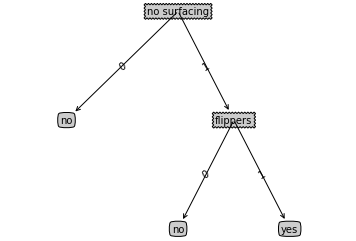

In [12]:
# test
testClass = [0,0,0,1,1,3,3,3,3,3,4]
print(majorityCnt(testClass))

Dat,label = createData()
myTree = createTree(Dat, label)
print(myTree)
createPlot(myTree)

In [13]:
def classify(inputTree, feaLabels, testVec):
    firstStr = list(inputTree.keys())[0]
    path = inputTree[firstStr]
    feaIndex = feaLabels.index(firstStr)
    for k,v in path.items():
        if k == testVec[feaIndex]:
            if type(v).__name__ == "dict":
                classLabel = classify(v, feaLabels, testVec)
            else:
                classLabel = v
    return classLabel

In [19]:

myTree = retrieveTree(0)
Dat,labels = createData()
print(labels)
print(myTree)
print(classify(myTree, labels, [1,0]))
print(classify(myTree, labels, [1,1]))

['no surfacing', 'flippers']
{'no surfacing': {0: 'no', 1: {'flippers': {0: 'no', 1: 'yes'}}}}
no
yes
